# Basic Small ResNet

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, utils, metrics
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Install kaggle
!pip install -q kaggle

# Upload kaggle.json (you'll get a button)
from google.colab import files
files.upload()

# Setup kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download + unzip dataset
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 143MB/s]



In [ ]:
train_ds = utils.image_dataset_from_directory("/content/seg_train/seg_train", image_size = (128, 128), batch_size = 32, seed = 123)

Found 14034 files belonging to 6 classes.


In [ ]:
class_names = train_ds.class_names

In [ ]:
num_batches = len(train_ds)

In [ ]:
test_size = int(0.1 * num_batches)

In [ ]:
test_ds = train_ds.take(test_size)
train_ds = train_ds.skip(test_size)

In [ ]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
val_ds = utils.image_dataset_from_directory("/content/seg_test/seg_test", image_size = (128, 128), batch_size = 32, shuffle = False)

Found 3000 files belonging to 6 classes.


In [ ]:
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
def residual_block(x, filters):

    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    if (shortcut[-1].shape != filters):
        shortcut = layers.Conv2D(filters, (1, 1), padding = 'same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

In [ ]:
def conv_model(input_shape):

     inputs = layers.Input(input_shape)

     x = layers.RandomFlip("horizontal")(inputs)
     x = layers.RandomRotation(0.1)(x)
     x = layers.RandomZoom(0.1)(x)

     x = layers.Rescaling(1./255)(x)

     x = layers.Conv2D(32, (3, 3), padding = 'same')(x)
     x = layers.BatchNormalization()(x)
     x = layers.Activation('relu')(x)

     x = residual_block(x, 32)
     x = residual_block(x, 32)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 64)
     x = residual_block(x, 64)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 128)
     x = residual_block(x, 128)

     x = layers.GlobalAveragePooling2D()(x)

     x = layers.Dropout(0.3)(x)

     outputs = layers.Dense(6, activation='softmax')(x)

     model = models.Model(inputs , outputs)

     return model

In [ ]:
resnet_model = conv_model((128, 128, 3))

In [ ]:
resnet_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history = resnet_model.fit(train_ds, epochs = 20, validation_data = val_ds)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.5819 - loss: 1.0692 - val_accuracy: 0.5267 - val_loss: 1.2473
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7133 - loss: 0.7752 - val_accuracy: 0.7890 - val_loss: 0.6126
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.7545 - loss: 0.6620 - val_accuracy: 0.6650 - val_loss: 1.0181
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.7725 - loss: 0.6122 - val_accuracy: 0.6330 - val_loss: 1.1785
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7951 - loss: 0.5738 - val_accuracy: 0.7850 - val_loss: 0.6544
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.8027 - loss: 0.5573 - val_accuracy: 0.7857 - val_loss: 0.5691
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8109 - loss: 0.5274 - val_accuracy: 0.6910 - val_loss: 0.9773
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8182 - loss: 0.5053 - 

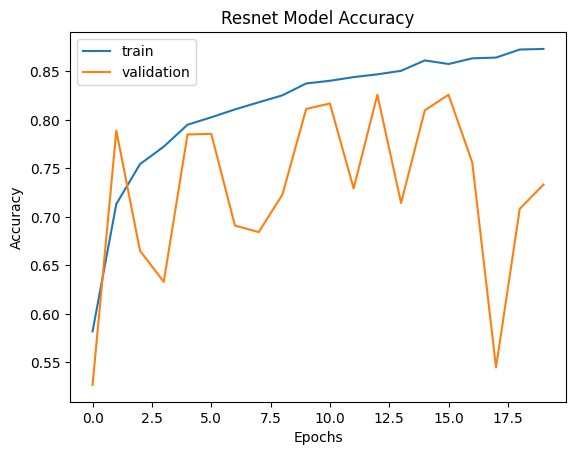

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Resnet Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.show()

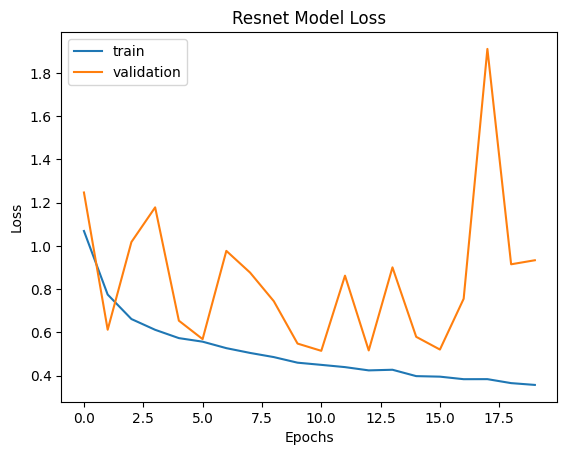

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Resnet Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = resnet_model.predict(images)   # predictions for THIS batch
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)                   # collect predictions
    y_true.extend(labels.numpy())          # collect true labels

# convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━

In [ ]:
print(len(y_true), len(y_pred))

1376 1376


In [ ]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[188   0   3   0   2  20]
 [ 37 173   1   1   3   2]
 [ 10   1 225   8  19   1]
 [ 38   0  48  76  86   0]
 [  4   0  10   0 208   0]
 [ 34   0   8   0   7 163]]
              precision    recall  f1-score   support

   buildings       0.60      0.88      0.72       213
      forest       0.99      0.80      0.88       217
     glacier       0.76      0.85      0.81       264
    mountain       0.89      0.31      0.46       248
         sea       0.64      0.94      0.76       222
      street       0.88      0.77      0.82       212

    accuracy                           0.75      1376
   macro avg       0.80      0.76      0.74      1376
weighted avg       0.80      0.75      0.74      1376



# Resnet without data augmentation

In [ ]:
def conv_model(input_shape):

     inputs = layers.Input(input_shape)

     # x = layers.RandomFlip("horizontal")(inputs)
     # x = layers.RandomRotation(0.1)(x)
     # x = layers.RandomZoom(0.1)(x)

     x = layers.Rescaling(1./255)(inputs)

     x = layers.Conv2D(32, (3, 3), padding = 'same')(x)
     x = layers.BatchNormalization()(x)
     x = layers.Activation('relu')(x)

     x = residual_block(x, 32)
     x = residual_block(x, 32)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 64)
     x = residual_block(x, 64)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 128)
     x = residual_block(x, 128)

     x = layers.GlobalAveragePooling2D()(x)

     x = layers.Dropout(0.3)(x)

     outputs = layers.Dense(6, activation='softmax')(x)

     model = models.Model(inputs , outputs)

     return model

In [ ]:
resnet_no_data_aug = conv_model((128, 128, 3))

In [ ]:
resnet_no_data_aug.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history1 = resnet_no_data_aug.fit(train_ds, epochs = 20, validation_data = val_ds)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.6440 - loss: 0.9038 - val_accuracy: 0.5763 - val_loss: 1.3261
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.7761 - loss: 0.6053 - val_accuracy: 0.7343 - val_loss: 0.7573
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8092 - loss: 0.5225 - val_accuracy: 0.4913 - val_loss: 2.1976
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8307 - loss: 0.4670 - val_accuracy: 0.6533 - val_loss: 1.3018
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8458 - loss: 0.4322 - val_accuracy: 0.7270 - val_loss: 0.8663
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8602 - loss: 0.3982 - val_accuracy: 0.7187 - val_loss: 0.8880
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8614 - loss: 0.3874 - val_accuracy: 0.7163 - val_loss: 0.9091
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8696 - loss: 0.3580 - 

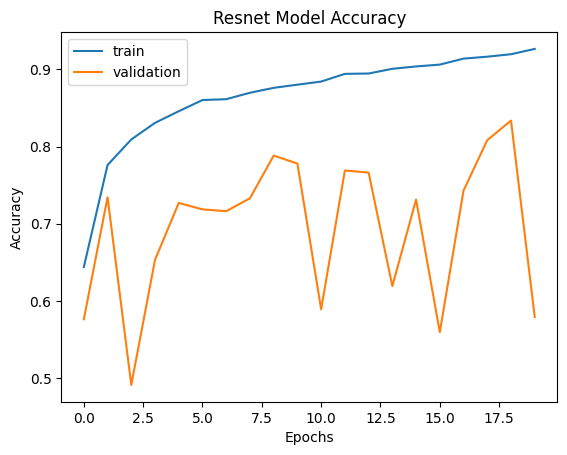

In [ ]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title("Resnet Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.show()

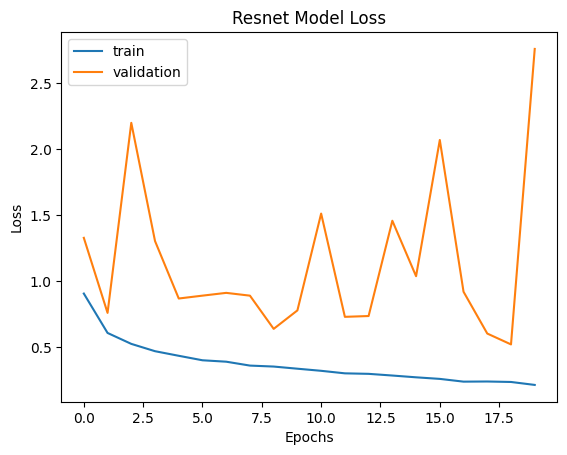

In [ ]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title("Resnet Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = resnet_no_data_aug.predict(images)   # predictions for THIS batch
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)                   # collect predictions
    y_true.extend(labels.numpy())          # collect true labels

# convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━

In [ ]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[ 73   0   7   0   1 139]
 [  0   8  51   2   2 154]
 [  0   0 247   5   4   4]
 [  0   0 153  86   7   1]
 [  0   0  35   4 171   7]
 [  1   0   5   0   0 209]]
              precision    recall  f1-score   support

   buildings       0.99      0.33      0.50       220
      forest       1.00      0.04      0.07       217
     glacier       0.50      0.95      0.65       260
    mountain       0.89      0.35      0.50       247
         sea       0.92      0.79      0.85       217
      street       0.41      0.97      0.57       215

    accuracy                           0.58      1376
   macro avg       0.78      0.57      0.52      1376
weighted avg       0.78      0.58      0.53      1376



# Resnet without Dropout

In [ ]:
def conv_model(input_shape):

     inputs = layers.Input(input_shape)

     x = layers.RandomFlip("horizontal")(inputs)
     x = layers.RandomRotation(0.1)(x)
     x = layers.RandomZoom(0.1)(x)

     x = layers.Rescaling(1./255)(x)

     x = layers.Conv2D(32, (3, 3), padding = 'same')(x)
     x = layers.BatchNormalization()(x)
     x = layers.Activation('relu')(x)

     x = residual_block(x, 32)
     x = residual_block(x, 32)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 64)
     x = residual_block(x, 64)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 128)
     x = residual_block(x, 128)

     x = layers.GlobalAveragePooling2D()(x)

     # x = layers.Dropout(0.3)(x)

     outputs = layers.Dense(6, activation='softmax')(x)

     model = models.Model(inputs , outputs)

     return model

In [ ]:
resnet_no_dropout = conv_model((128, 128, 3))

In [ ]:
resnet_no_dropout.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history2 = resnet_no_dropout.fit(train_ds, epochs = 20, validation_data = val_ds)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.6290 - loss: 0.9613 - val_accuracy: 0.5857 - val_loss: 1.3274
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7443 - loss: 0.6962 - val_accuracy: 0.6630 - val_loss: 0.9974
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7809 - loss: 0.6088 - val_accuracy: 0.5573 - val_loss: 1.4604
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7900 - loss: 0.5794 - val_accuracy: 0.7117 - val_loss: 0.7639
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8100 - loss: 0.5354 - val_accuracy: 0.6557 - val_loss: 1.1070
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8257 - loss: 0.4925 - val_accuracy: 0.7550 - val_loss: 0.7555
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.8352 - loss: 0.4702 - val_accuracy: 0.7800 - val_loss: 0.6185
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.8403 - loss: 0.4505 - 

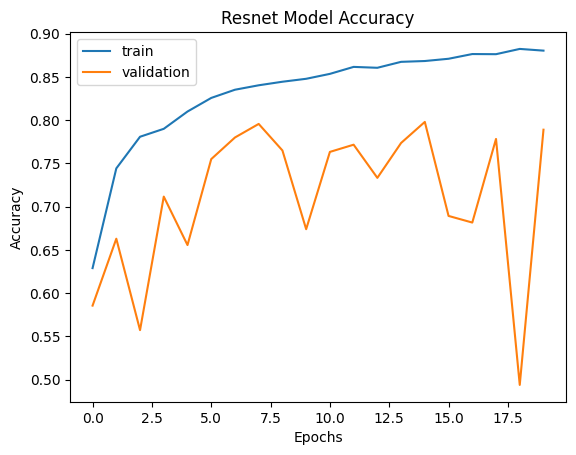

In [ ]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title("Resnet Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.show()

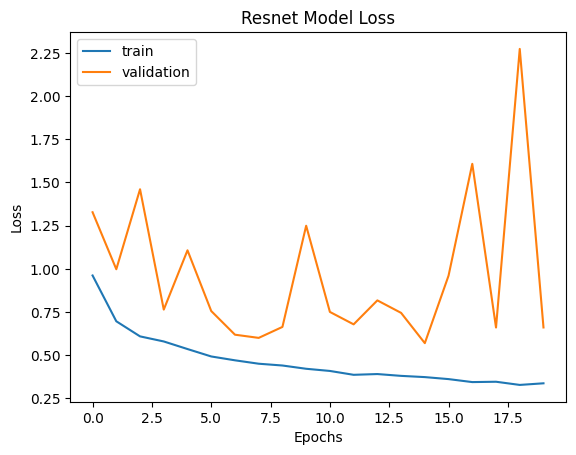

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title("Resnet Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = resnet_no_dropout.predict(images)   # predictions for THIS batch
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)                   # collect predictions
    y_true.extend(labels.numpy())          # collect true labels

# convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━

In [ ]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[194   0   0   3   1  19]
 [ 20 197   1   0   2   5]
 [ 13   2 170  46  24   2]
 [ 32   0  19 152  47   0]
 [  8   1   5   4 192   0]
 [ 32   0   1   0   1 183]]
              precision    recall  f1-score   support

   buildings       0.65      0.89      0.75       217
      forest       0.98      0.88      0.93       225
     glacier       0.87      0.66      0.75       257
    mountain       0.74      0.61      0.67       250
         sea       0.72      0.91      0.81       210
      street       0.88      0.84      0.86       217

    accuracy                           0.79      1376
   macro avg       0.81      0.80      0.79      1376
weighted avg       0.81      0.79      0.79      1376



# Resnet with different learning rate

In [ ]:
def conv_model(input_shape):

     inputs = layers.Input(input_shape)

     x = layers.RandomFlip("horizontal")(inputs)
     x = layers.RandomRotation(0.1)(x)
     x = layers.RandomZoom(0.1)(x)

     x = layers.Rescaling(1./255)(x)

     x = layers.Conv2D(32, (3, 3), padding = 'same')(x)
     x = layers.BatchNormalization()(x)
     x = layers.Activation('relu')(x)

     x = residual_block(x, 32)
     x = residual_block(x, 32)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 64)
     x = residual_block(x, 64)

     x = layers.MaxPooling2D((2, 2))(x)

     x = residual_block(x, 128)
     x = residual_block(x, 128)

     x = layers.GlobalAveragePooling2D()(x)

     x = layers.Dropout(0.3)(x)

     outputs = layers.Dense(6, activation='softmax')(x)

     model = models.Model(inputs , outputs)

     return model

In [ ]:
resnet_diff_learning_rate = conv_model((128, 128, 3))

In [ ]:
resnet_diff_learning_rate.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history3 = resnet_diff_learning_rate.fit(train_ds, epochs = 20, validation_data = val_ds)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.5646 - loss: 1.1039 - val_accuracy: 0.4377 - val_loss: 1.5685
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.6726 - loss: 0.8622 - val_accuracy: 0.6233 - val_loss: 1.1049
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7203 - loss: 0.7575 - val_accuracy: 0.6693 - val_loss: 0.9870
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7507 - loss: 0.6828 - val_accuracy: 0.7107 - val_loss: 0.8637
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7692 - loss: 0.6366 - val_accuracy: 0.5483 - val_loss: 1.7038
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7823 - loss: 0.6007 - val_accuracy: 0.7637 - val_loss: 0.6646
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7934 - loss: 0.5707 - val_accuracy: 0.5773 - val_loss: 1.3986
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8067 - loss: 0.5333 - 

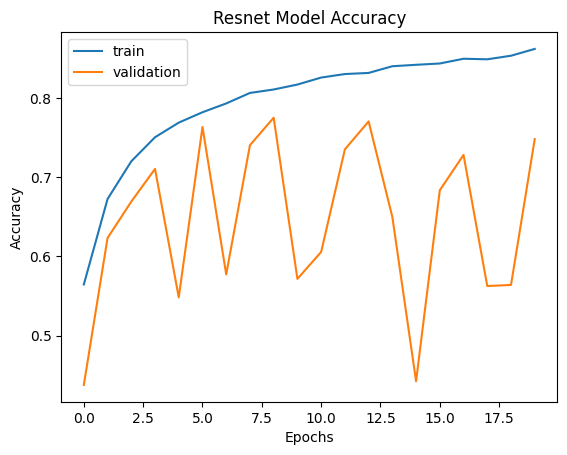

In [ ]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title("Resnet Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.show()

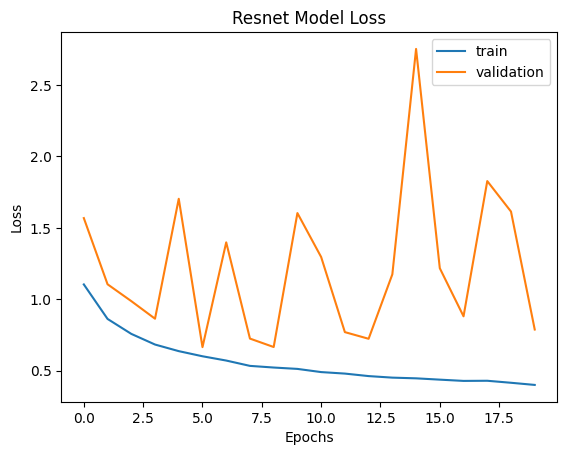

In [ ]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title("Resnet Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = resnet_diff_learning_rate.predict(images)   # predictions for THIS batch
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)                   # collect predictions
    y_true.extend(labels.numpy())          # collect true labels

# convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━

In [ ]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[198   4   0   0   1  22]
 [ 13 202   0   1   2   1]
 [ 46   2 143  31  30   0]
 [ 35   1  13 158  36   0]
 [ 18   2   6   7 187   0]
 [ 52   2   1   0   1 161]]
              precision    recall  f1-score   support

   buildings       0.55      0.88      0.67       225
      forest       0.95      0.92      0.94       219
     glacier       0.88      0.57      0.69       252
    mountain       0.80      0.65      0.72       243
         sea       0.73      0.85      0.78       220
      street       0.88      0.74      0.80       217

    accuracy                           0.76      1376
   macro avg       0.80      0.77      0.77      1376
weighted avg       0.80      0.76      0.76      1376

